In [1]:
# ============================================
# New Car Sales by Make.csv
# K-Means Clustering + NLP Features in Jupyter
# ============================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score

# Optional: cleaner plots
plt.rcParams["figure.figsize"] = (10, 6)

# 2. LOAD DATA
file_path = "New Car Sales by Make.csv"
df = pd.read_csv(file_path)

# 3. PREVIEW DATA
print("First 5 rows:")
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nData info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:


,Year,Month,Make,Quantity,Pct
0,2007,1,Toyota,2884,22.7
1,2007,1,Volkswagen,2521,19.9
2,2007,1,Peugeot,1029,8.1
3,2007,1,Ford,870,6.9
4,2007,1,Volvo,693,5.5



Columns:
['Year', 'Month', 'Make', 'Quantity', 'Pct']

Data info:
<class 'pandas.DataFrame'>
RangeIndex: 4377 entries, 0 to 4376
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Year      4377 non-null   int64  
 1   Month     4377 non-null   int64  
 2   Make      4367 non-null   str    
 3   Quantity  4377 non-null   int64  
 4   Pct       4377 non-null   float64
dtypes: float64(1), int64(3), str(1)
memory usage: 198.4 KB
None

Missing values:
Year         0
Month        0
Make        10
Quantity     0
Pct          0
dtype: int64


In [2]:
# 4. CLEAN COLUMN NAMES
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace(r"[^\w]", "", regex=True)

print("Cleaned columns:")
print(df.columns.tolist())

Cleaned columns:
['Year', 'Month', 'Make', 'Quantity', 'Pct']


In [5]:
df = df.convert_dtypes()

In [6]:
# 6. BASIC CLEANING FOR TEXT COLUMNS
for col in text_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()

display(df.head())

,Year,Month,Make,Quantity,Pct
0,2007,1,toyota,2884,22.7
1,2007,1,volkswagen,2521,19.9
2,2007,1,peugeot,1029,8.1
3,2007,1,ford,870,6.9
4,2007,1,volvo,693,5.5


In [8]:
# Clean the column before TF-IDF
df[make_col] = df[make_col].fillna("").astype(str)

# Now run TF-IDF
tfidf = TfidfVectorizer(stop_words="english")
make_tfidf = tfidf.fit_transform(df[make_col])

print("TF-IDF matrix shape:", make_tfidf.shape)
print("Sample TF-IDF feature names:", tfidf.get_feature_names_out()[:20])

TF-IDF matrix shape: (4377, 68)
Sample TF-IDF feature names: ['alfa' 'aston' 'audi' 'bentley' 'benz' 'binz' 'bmw' 'cadillac'
 'chevrolet' 'chrysler' 'citroen' 'dacia' 'daihatsu' 'dodge' 'ds'
 'ferrari' 'fiat' 'fisker' 'ford' 'honda']


In [9]:
# 8. PREPARE NUMERIC DATA FOR K-MEANS
# Use numeric columns only for clustering sales patterns

if len(numeric_cols) == 0:
    raise ValueError("No numeric columns found for clustering.")

numeric_data = df[numeric_cols].copy()

# Fill missing numeric values with mean
imputer = SimpleImputer(strategy="mean")
numeric_data_imputed = imputer.fit_transform(numeric_data)

# Standardize numeric data
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(numeric_data_imputed)

print("Scaled numeric data shape:", numeric_scaled.shape)

Scaled numeric data shape: (4377, 4)


In [10]:
# 9. OPTIONAL: COMBINE NUMERIC + NLP FEATURES
# Convert sparse TF-IDF to dense carefully if dataset is small
# If your dataset is very large, skip combining to avoid memory issues

combine_features = True

if combine_features:
    if make_tfidf.shape[0] < 5000:
        combined_features = np.hstack([numeric_scaled, make_tfidf.toarray()])
        print("Combined feature shape:", combined_features.shape)
    else:
        print("Dataset too large for safe dense TF-IDF conversion. Using numeric features only.")
        combined_features = numeric_scaled
else:
    combined_features = numeric_scaled

Combined feature shape: (4377, 72)


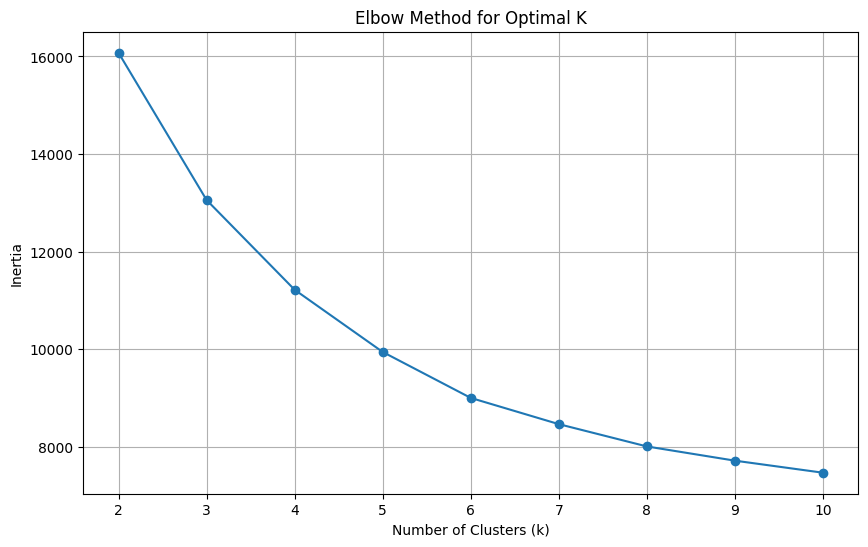

In [11]:
# 10. FIND A GOOD K USING ELBOW METHOD
inertia_values = []
k_range = range(2, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(combined_features)
    inertia_values.append(model.inertia_)

plt.plot(list(k_range), inertia_values, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

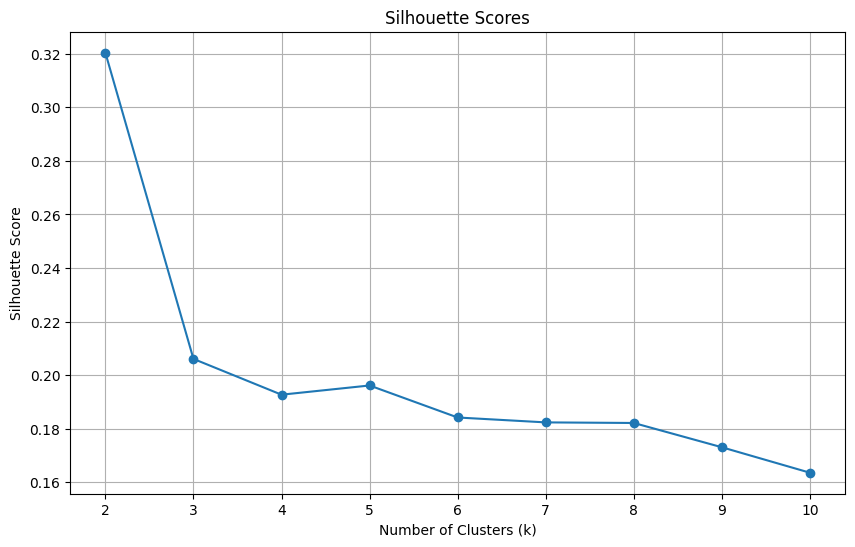

Best k based on silhouette score: 2


In [12]:
# 11. SILHOUETTE SCORES
sil_scores = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(combined_features)
    score = silhouette_score(combined_features, labels)
    sil_scores.append(score)

plt.plot(list(k_range), sil_scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

best_k = list(k_range)[np.argmax(sil_scores)]
print("Best k based on silhouette score:", best_k)

In [13]:
# 12. TRAIN FINAL K-MEANS MODEL
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(combined_features)

display(df.head())
print(df["Cluster"].value_counts())

,Year,Month,Make,Quantity,Pct,Cluster
0,2007,1,toyota,2884,22.7,1
1,2007,1,volkswagen,2521,19.9,1
2,2007,1,peugeot,1029,8.1,1
3,2007,1,ford,870,6.9,1
4,2007,1,volvo,693,5.5,1


Cluster
0    3554
1     823
Name: count, dtype: int64


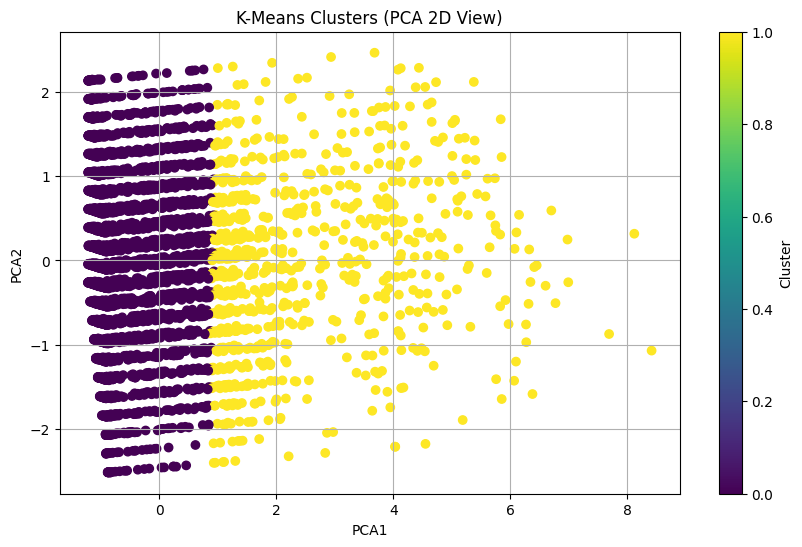

In [14]:
# 13. PCA FOR 2D VISUALIZATION
pca = PCA(n_components=2)
pca_components = pca.fit_transform(combined_features)

df["PCA1"] = pca_components[:, 0]
df["PCA2"] = pca_components[:, 1]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df["PCA1"], df["PCA2"], c=df["Cluster"], cmap="viridis")
plt.title("K-Means Clusters (PCA 2D View)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

In [15]:
# 14. CLUSTER SUMMARY
cluster_summary = df.groupby("Cluster")[numeric_cols].mean()
display(cluster_summary)

,Year,Month,Quantity,Pct
Cluster,,,,
0,2011.222566,6.458075,149.561621,1.38081
1,2012.27825,6.467801,991.139733,8.727825


In [16]:
# 15. MOST COMMON MAKES BY CLUSTER
make_cluster_summary = df.groupby("Cluster")[make_col].value_counts().groupby(level=0).head(10)
print(make_cluster_summary)

Cluster  Make         
0        lexus            122
         honda            121
         citroen          121
         suzuki           121
         renault          121
         kia              121
         mini             121
         land rover       121
         fiat             121
         subaru           120
1        volkswagen       121
         toyota           121
         ford             118
         volvo            105
         audi              70
         bmw               57
         skoda             57
         nissan            50
         peugeot           35
         mercedes-benz     31
Name: count, dtype: int64


In [17]:
# 16. SAVE RESULT
output_file = "car_sales_clustered_output.csv"
df.to_csv(output_file, index=False)
print(f"Clustered dataset saved as: {output_file}")

Clustered dataset saved as: car_sales_clustered_output.csv
